# Transformers

A continuación se muestran los modelos transformers creados para predecir la efectividad de los informes.

In [ ]:
# !git clone https://github.com/chuy-zip/PROYECTO2_DS.git

Cloning into 'PROYECTO2_DS'...
remote: Enumerating objects: 4282, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 4282 (delta 7), reused 12 (delta 3), pack-reused 4264 (from 2)
Receiving objects: 100% (4282/4282), 62.87 MiB | 35.12 MiB/s, done.
Resolving deltas: 100% (33/33), done.


## Preparacion de datos

Se decidio poner a prueba la solución propuesta de los ganadores de la competencia sobre este conjunto datos.

https://www.kaggle.com/competitions/feedback-prize-effectiveness/writeups/team-hydrogen-team-hydrogen-1st-place-solution

Partieron del enfoque que las diferentes secciones de un ensayo realmente son interdependientes, por ejemplo un buen argumento depende que anteriormente se haya hecho una buena introducción. Para poder mantener este contexto las **piezas de un ensayo y su calificación debería hacer como un todo**. Es por ello que los datos fueron preparados de una forma diferente, este es un ejemplo de un input para el modelo.

> Lead Position Claim Evidence Counterclaim Rebuttal Evidence Counterclaim Concluding Statement [SEP]  [START] Hi, i'm Isaac, i'm going to be writing about how this face on Mars is a natural landform or if there is life on Mars that made it. The story is about how NASA took a picture of Mars and a face was seen on the planet. NASA doesn't know if the landform was created by life on Mars, or if it is just a natural landform. [END]   [START] On my perspective, I think that the face is a natural landform because I dont think that there is any life on Mars. In these next few paragraphs, I'll be talking about how I think that is is a natural landform [END] … more text follows here

**Estructura**
Al principio del todo se indican en orden las secciones que conforman el ensayo. Justo después se muestra el ensayo completo, utilizando las palabras `[SEP]` y `[START]`, para indicar cuando empieza y termina un sección.

Añadido a esto se crea un vector con las puntuaciones de de cada sección usando la codificacion de :

- Inefectivo = 0
- Adecuado = 1
- Effectivo = 2

De tal manera que al encodificar un ensayo se obtiene 2 valores

1. El texto ensayo completo con los tokens separadores
2. Vector de punteos de cada sección

In [1]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, AutoConfig
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.model_selection import train_test_split


torch.cuda.empty_cache()

ModuleNotFoundError: No module named 'transformers'

In [67]:
def format_essay(essay_df):
    """
    Takes all discourses from one essay and formats them into the required input.

    Args:
        essay_df: DataFrame containing all discourses for a single essay

    Returns:
        formatted_text: String in the required format
        labels: List of effectiveness labels (0=Inadequate, 1=Adequate, 2=Effective)
    """
    # Step 1: Create the discourse type header
    discourse_types = essay_df['discourse_type'].tolist()
    header = ' '.join(discourse_types)

    # Step 2: Format each discourse with [START] and [END] markers
    discourse_parts = []
    labels = []

    label_map = {'Ineffective': 0, 'Adequate': 1, 'Effective': 2}

    for _, row in essay_df.iterrows():
        text = row['discourse_text'].strip()
        discourse_part = f"[START] {text} [END]"
        discourse_parts.append(discourse_part)

        # Store the label
        labels.append(label_map[row['discourse_effectiveness']])

    # Step 3: Combine everything
    formatted_text = header + " [SEP] " + " ".join(discourse_parts)

    return formatted_text, labels


df = pd.read_csv('./PROYECTO2_DS/data/train.csv')
label_map = {'Ineffective': 0, 'Adequate': 1, 'Effective': 2}
reverse_label_map = {v: k for k, v in label_map.items()}

# Let's format the first essay as an example
first_essay_id = df['essay_id'].iloc[0]
essay_df = df[df['essay_id'] == first_essay_id]
formatted_text, labels = format_essay(essay_df)

print("FORMATTED TEXT:")
print("=" * 80)
print(formatted_text)
print("\n" + "=" * 80)
print(f"\nSCORE VECTOR: {labels}")
print(f"Number of discourses: {len(labels)}")

# Let's also format ALL essays and save them
print("\n" + "=" * 80)
print("Formatting all essays...")

all_formatted_data = []
all_labels = []


for essay_id in df['essay_id'].unique():
    essay_df = df[df['essay_id'] == essay_id]
    formatted_text, labels = format_essay(essay_df)

    all_labels.extend(labels)

    all_formatted_data.append({
        'essay_id': essay_id,
        'formatted_text': formatted_text,
        'labels': labels,
        'num_discourses': len(labels),
        'text_length': len(formatted_text)  # Add character count
    })


# Convert to DataFrame and save
formatted_df = pd.DataFrame(all_formatted_data)

print(f"Formatted {len(formatted_df)} essays!")

# Show statistics
print(f"\nStatistics:")
print(f"  Total essays: {len(formatted_df)}")
print(f"  Avg discourses per essay: {formatted_df['num_discourses'].mean():.1f}")
print(f"  Max discourses in an essay: {formatted_df['num_discourses'].max()}")
print(f"  Min discourses in an essay: {formatted_df['num_discourses'].min()}")
print(f"\n  Text Length (characters):")
print(f"    Average: {formatted_df['text_length'].mean():.0f}")
print(f"    Maximum: {formatted_df['text_length'].max()}")
print(f"    Minimum: {formatted_df['text_length'].min()}")
print(f"    Median: {formatted_df['text_length'].median():.0f}")

# Calculate approximate token length (rough estimate: 1 token ≈ 4 characters)
formatted_df['approx_tokens'] = formatted_df['text_length'] / 4

print(f"\n  Estimated Token Length (approx):")
print(f"    Average: {formatted_df['approx_tokens'].mean():.0f}")
print(f"    Maximum: {formatted_df['approx_tokens'].max():.0f}")
print(f"    Minimum: {formatted_df['approx_tokens'].min():.0f}")
print(f"    Median: {formatted_df['approx_tokens'].median():.0f}")

# Check how many essays exceed common max_length values
print(f"\n  Essays exceeding token limits:")
print(f"    > 512 tokens: {(formatted_df['approx_tokens'] > 512).sum()} ({(formatted_df['approx_tokens'] > 512).mean()*100:.1f}%)")
print(f"    > 1024 tokens: {(formatted_df['approx_tokens'] > 1024).sum()} ({(formatted_df['approx_tokens'] > 1024).mean()*100:.1f}%)")
print(f"    > 2048 tokens: {(formatted_df['approx_tokens'] > 2048).sum()} ({(formatted_df['approx_tokens'] > 2048).mean()*100:.1f}%)")

del formatted_df
del all_formatted_data

FORMATTED TEXT:
Lead Position Claim Evidence Counterclaim Rebuttal Evidence Counterclaim Concluding Statement [SEP] [START] Hi, i'm Isaac, i'm going to be writing about how this face on Mars is a natural landform or if there is life on Mars that made it. The story is about how NASA took a picture of Mars and a face was seen on the planet. NASA doesn't know if the landform was created by life on Mars, or if it is just a natural landform. [END] [START] On my perspective, I think that the face is a natural landform because I dont think that there is any life on Mars. In these next few paragraphs, I'll be talking about how I think that is is a natural landform [END] [START] I think that the face is a natural landform because there is no life on Mars that we have descovered yet [END] [START] If life was on Mars, we would know by now. The reason why I think it is a natural landform because, nobody live on Mars in order to create the figure. It says in paragraph 9, "It's not easy to target Cy


===== DISTRIBUCIÓN DE ETIQUETAS =====
Ineffective : 6462
Adequate    : 20977
Effective   : 9326

Total de discursos: 36765

Proporción por clase:
Ineffective : 17.58%
Adequate    : 57.06%
Effective   : 25.37%


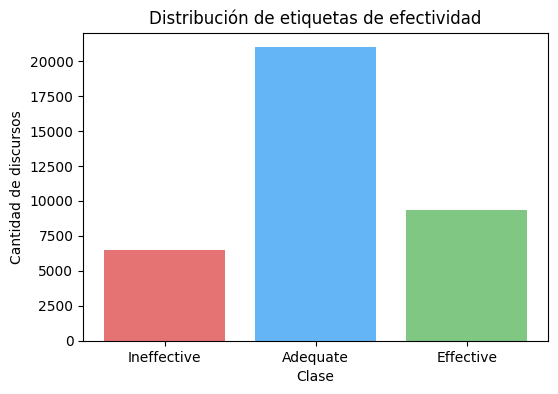

In [68]:
label_counts = pd.Series(all_labels).value_counts().sort_index()
label_names = [reverse_label_map[i] for i in label_counts.index]

print("\n===== DISTRIBUCIÓN DE ETIQUETAS =====")
for name, count in zip(label_names, label_counts):
    print(f"{name:<12}: {count}")

print(f"\nTotal de discursos: {sum(label_counts)}")

# ✅ Mostrar proporciones
print("\nProporción por clase:")
for name, count in zip(label_names, label_counts):
    print(f"{name:<12}: {count / sum(label_counts):.2%}")

# ✅ Gráfica de barras
plt.figure(figsize=(6,4))
plt.bar(label_names, label_counts, color=['#e57373','#64b5f6','#81c784'])
plt.title("Distribución de etiquetas de efectividad")
plt.ylabel("Cantidad de discursos")
plt.xlabel("Clase")
plt.show()

Arriba hay un ejemplo de la codificación de un solo ensayo.

### DataLoader

Para evitar cargar todos los datos en memoria se implemento una clase DataLoader para cargar los datos en baches que seran cargados y liberados cada cierto tiempo. **Cada bache esta compuesto por un solo ensayo y todas sus secciones** justo como se menciono en la sección anterior.

In [69]:
class SimpleEssayDataset(Dataset):
    """
    Minimal Dataset class that PyTorch DataLoader needs.
    Just handles tokenization and organizing the data.
    """

    def __init__(self, csv_path, tokenizer_name='microsoft/deberta-v3-large', max_length=1024):
        # Load CSV and group by essay
        df = pd.read_csv(csv_path)
        self.essay_ids = df['essay_id'].unique()
        self.df = df
        self.max_length = max_length

        # Initialize tokenizer (use_fast=False to avoid conversion errors)
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

        # Add special tokens [START] and [END]
        self.tokenizer.add_special_tokens({
            'additional_special_tokens': ['[START]', '[END]']
        })

        print(f"Loaded {len(self.essay_ids)} essays")
        print(f"Tokenizer vocabulary size: {len(self.tokenizer)}")

    def __len__(self):
        """Returns the number of essays in the dataset"""
        return len(self.essay_ids)

    def __getitem__(self, idx):
        """
        Get one essay and return it tokenized.

        Returns a dictionary with:
            - essay_id: The essay identifier
            - input_ids: Tokenized text (tensor of token IDs)
            - attention_mask: Mask for padding tokens
            - labels: Effectiveness labels for each discourse
            - formatted_text: The formatted text (for debugging)
        """
        # Get one essay
        essay_id = self.essay_ids[idx]
        essay_df = self.df[self.df['essay_id'] == essay_id]

        # Format it
        formatted_text, labels = format_essay(essay_df)

        # Tokenize it (convert text to numbers)
        encoding = self.tokenizer(
            formatted_text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )

        return {
            'essay_id': essay_id,
            'input_ids': encoding['input_ids'].squeeze(0),  # Remove batch dimension
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(labels, dtype=torch.long),
            'num_discourses': len(labels),
            'formatted_text': formatted_text  # Keep for debugging
        }

A continuación una pequeña prueba del dataset usando el modelo preentrenado **`deberta-base`**, esto incluye el su *tokenizador* y el *modelo* en si.

In [70]:
# Create dataset
print("Creating dataset...")
dataset = SimpleEssayDataset(
    csv_path='./PROYECTO2_DS/data/train.csv',
    tokenizer_name='microsoft/deberta-base',
    max_length=2048
)

print(f"\nDataset has {len(dataset)} essays")

# Look at one example
print("\n" + "=" * 80)
print("EXAMPLE 1: Getting a single essay")
print("=" * 80)

sample = dataset[0]

print(f"Essay ID: {sample['essay_id']}")
print(f"Number of discourses: {sample['num_discourses']}")
print(f"Input IDs shape: {sample['input_ids'].shape}")
print(f"Attention mask shape: {sample['attention_mask'].shape}")
print(f"Labels: {sample['labels']}")
print(f"Labels shape: {sample['labels'].shape}")

# Decode the tokens to see the formatted text
decoded_text = dataset.tokenizer.decode(sample['input_ids'], skip_special_tokens=False)
print(f"\nFormatted text (first 600 characters):")
print(decoded_text[:600])

# Create DataLoader
print("\n" + "=" * 80)
print("EXAMPLE 2: Using with DataLoader")
print("=" * 80)

dataloader = DataLoader(
    dataset,
    batch_size=1,  # Process one essay at a time
    shuffle=True
)

# Get one batch
batch = next(iter(dataloader))

print(f"Batch essay ID: {batch['essay_id']}")
print(f"Batch input_ids shape: {batch['input_ids'].shape}")  # [1, max_length]
print(f"Batch labels shape: {batch['labels'].shape}")  # [1, num_discourses]
print(f"Batch labels: {batch['labels']}")

# Iterate through a few batches
print("\n" + "=" * 80)
print("EXAMPLE 3: Iterating through batches")
print("=" * 80)

for i, batch in enumerate(dataloader):
    if i >= 3:  # Just show first 3
        break

    print(f"\nBatch {i+1}:")
    print(f"  Essay ID: {batch['essay_id'][0]}")
    print(f"  Num discourses: {batch['num_discourses'].item()}")
    print(f"  Labels: {batch['labels'][0].tolist()}")

print("\n" + "=" * 80)
print("Dataset is ready to use for training!")
print("=" * 80)

Creating dataset...
Loaded 4191 essays
Tokenizer vocabulary size: 50267

Dataset has 4191 essays

EXAMPLE 1: Getting a single essay
Essay ID: 007ACE74B050
Number of discourses: 9
Input IDs shape: torch.Size([2048])
Attention mask shape: torch.Size([2048])
Labels: tensor([1, 1, 1, 1, 1, 0, 1, 1, 1])
Labels shape: torch.Size([9])

Formatted text (first 600 characters):
[CLS]Lead Position Claim Evidence Counterclaim Rebuttal Evidence Counterclaim Concluding Statement [SEP] [START] Hi, i'm Isaac, i'm going to be writing about how this face on Mars is a natural landform or if there is life on Mars that made it. The story is about how NASA took a picture of Mars and a face was seen on the planet. NASA doesn't know if the landform was created by life on Mars, or if it is just a natural landform. [END] [START] On my perspective, I think that the face is a natural landform because I dont think that there is any life on Mars. In these next few paragraphs, I'll be ta

EXAMPLE 2: Using with DataLo

## Modelo

Para el modelo, se estará utilizando un modelo pre-entrenado al que se estara realizando algunas modificaciones para que pueda dar el resultado correcto.

La idea principal es entrenarlo con **1 ensayo a la vez y prediciendo el puntaje para cada sección** , es decir:

`1 input -> N ouputs`

Donde N es el conjunto de secciones que conforman el input.

In [6]:
class EssayGroupModel(nn.Module):
    """
    Model that processes full essays and predicts effectiveness for each discourse.

    How it works:
    1. Takes ONE full essay as input
    2. Passes it through the backbone (DeBERTa/RoBERTa)
    3. Pools embeddings between [START] and [END] tokens for each discourse
    4. Predicts effectiveness for each discourse independently
    """

    def __init__(
        self,
        model_name='microsoft/deberta-base',
        num_labels=3,  # Inadequate, Adequate, Effective
        dropout=0.1
    ):
        super().__init__()

        # Load pretrained backbone
        print(f"Loading pretrained model: {model_name}")
        self.backbone = AutoModel.from_pretrained(model_name)
        self.config = self.backbone.config
        self.hidden_size = self.config.hidden_size

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # Final classification layer
        self.classifier = nn.Linear(self.hidden_size, num_labels)

        print(f"Model initialized with hidden_size={self.hidden_size}")

    def resize_token_embeddings(self, new_num_tokens):
        """
        Call this after adding special tokens to the tokenizer.
        This resizes the model's embedding layer to accommodate new tokens.
        """
        self.backbone.resize_token_embeddings(new_num_tokens)
        print(f"Resized token embeddings to {new_num_tokens}")

    def find_start_end_positions(self, input_ids, start_token_id, end_token_id):
        """
        Find all [START] and [END] token positions in the input.

        Args:
            input_ids: [seq_len] tensor of token IDs
            start_token_id: ID of [START] token
            end_token_id: ID of [END] token

        Returns:
            start_positions: List of start token positions
            end_positions: List of end token positions
        """
        start_positions = []
        end_positions = []

        for i, token_id in enumerate(input_ids):
            if token_id == start_token_id:
                start_positions.append(i)
            elif token_id == end_token_id:
                end_positions.append(i)

        return start_positions, end_positions

    def pool_discourse_embeddings(self, sequence_output, start_positions, end_positions):
        """
        Pool embeddings between [START] and [END] tokens for each discourse.

        Args:
            sequence_output: [seq_len, hidden_size] - output from backbone
            start_positions: List of start token positions
            end_positions: List of end token positions

        Returns:
            pooled_embeddings: [num_discourses, hidden_size]
        """
        num_discourses = len(start_positions)
        pooled_embeddings = []

        for i in range(num_discourses):
            start_idx = start_positions[i]
            end_idx = end_positions[i]

            # Extract tokens between START and END (exclusive of the markers)
            # discourse_embeddings shape: [num_tokens_in_discourse, hidden_size]
            discourse_embeddings = sequence_output[start_idx + 1:end_idx]

            if len(discourse_embeddings) == 0:
                # If empty (shouldn't happen), use the START token
                pooled = sequence_output[start_idx]
            else:
                # Mean pooling
                pooled = discourse_embeddings.mean(dim=0)

            pooled_embeddings.append(pooled)

        # Stack into tensor: [num_discourses, hidden_size]
        pooled_embeddings = torch.stack(pooled_embeddings, dim=0)

        return pooled_embeddings

    def forward(self, input_ids, attention_mask, start_token_id, end_token_id, labels=None):
        """
        Forward pass.

        Args:
            input_ids: [batch_size=1, seq_len] - tokenized essay
            attention_mask: [batch_size=1, seq_len] - attention mask
            start_token_id: int - ID of [START] token
            end_token_id: int - ID of [END] token
            labels: [num_discourses] - effectiveness labels (optional, for training)

        Returns:
            Dictionary with:
                - loss: scalar (if labels provided)
                - logits: [num_discourses, 3] - predictions for each discourse
                - probabilities: [num_discourses, 3] - softmax probabilities
        """
        # Pass through backbone
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Get sequence output: [batch_size=1, seq_len, hidden_size]
        sequence_output = outputs.last_hidden_state

        # Remove batch dimension since we process one essay at a time
        sequence_output = sequence_output.squeeze(0)  # [seq_len, hidden_size]
        input_ids_1d = input_ids.squeeze(0)  # [seq_len]

        # Find [START] and [END] positions
        start_positions, end_positions = self.find_start_end_positions(
            input_ids_1d, start_token_id, end_token_id
        )

        # Pool embeddings for each discourse
        pooled_embeddings = self.pool_discourse_embeddings(
            sequence_output, start_positions, end_positions
        )  # [num_discourses, hidden_size]

        # Apply dropout
        pooled_embeddings = self.dropout(pooled_embeddings)

        # Get logits for each discourse
        logits = self.classifier(pooled_embeddings)  # [num_discourses, 3]

        # Calculate probabilities
        probabilities = torch.softmax(logits, dim=-1)

        # Calculate loss if labels provided
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {
            'loss': loss,
            'logits': logits,
            'probabilities': probabilities,
            'num_discourses': len(start_positions)
        }




**Probando el modelo**

Para verificar que todas el modelo funciona bien, se hizo una pequeña aislada con datos de prueba para comprobar que los inputs y outputs eran los requeridos.

In [7]:
# Initialize model
model = EssayGroupModel(
    model_name='microsoft/deberta-base',
    num_labels=3,
    dropout=0.1
)

# Initialize tokenizer and add special tokens
tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-base', use_fast=False)
tokenizer.add_special_tokens({
    'additional_special_tokens': ['[START]', '[END]']
})

# IMPORTANT: Resize model embeddings after adding tokens
model.resize_token_embeddings(len(tokenizer))

print(f"\nModel Summary:")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Create a dummy batch to test
dummy_text = "Lead Position [SEP] [START] This is the first discourse. [END] [START] This is the second discourse. [END]"

encoding = tokenizer(
    dummy_text,
    return_tensors='pt',
    max_length=512,
    padding='max_length',
    truncation=True
)

dummy_labels = torch.tensor([1, 2])  # Adequate, Effective

# Test forward pass
print("\nTesting forward pass...")
outputs = model(
    input_ids=encoding['input_ids'],
    attention_mask=encoding['attention_mask'],
    start_token_id=tokenizer.convert_tokens_to_ids('[START]'),
    end_token_id=tokenizer.convert_tokens_to_ids('[END]'),
    labels=dummy_labels
)

print(f"  Loss: {outputs['loss'].item():.4f}")
print(f"  Logits shape: {outputs['logits'].shape}")
print(f"  Probabilities shape: {outputs['probabilities'].shape}")
print(f"  Number of discourses found: {outputs['num_discourses']}")
print(f"  Predictions:\n{outputs['probabilities']}")

print("\n✅ Model is ready to train!")

Loading pretrained model: microsoft/deberta-base


pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Model initialized with hidden_size=768


model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Resized token embeddings to 50267

Model Summary:
  Total parameters: 138,605,571
  Trainable parameters: 138,605,571

Testing forward pass...
  Loss: 1.3636
  Logits shape: torch.Size([2, 3])
  Probabilities shape: torch.Size([2, 3])
  Number of discourses found: 2
  Predictions:
tensor([[0.5408, 0.3191, 0.1401],
        [0.4639, 0.3311, 0.2050]], grad_fn=<SoftmaxBackward0>)

✅ Model is ready to train!


Como se puede observar el modelo devolvio una matriz de predicciones

- Cada fila contiene las predicciones para cada sección.
- Cade valor representa una probabiliad que es sección pertenezca a cierta categoria (efectivo, inadecuado, adecuado).

Ejemplo:

```python
[[0.2585, 0.5441, 0.1973],
[0.2399, 0.4953, 0.2648]]
```

La seccion 1 tine 22,85 probabilidades de ser inadecuada, 54% de ser adecuada y 19% de ser effectiva

### Entrenamiento


In [8]:
def train_step(model, batch, optimizer, device, tokenizer):
    """
    Single training step for one essay.

    Args:
        model: The EssayGroupModel
        batch: Dictionary from DataLoader
        optimizer: PyTorch optimizer
        device: 'cuda' or 'cpu'
        tokenizer: The tokenizer (to get special token IDs)

    Returns:
        loss: float - loss value
        num_discourses: int - number of discourses in this essay
    """
    model.train()

    # Move to device
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].squeeze(0).to(device)  # Remove batch dimension

    # Get special token IDs
    start_token_id = tokenizer.convert_tokens_to_ids('[START]')
    end_token_id = tokenizer.convert_tokens_to_ids('[END]')

    # Forward pass
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        start_token_id=start_token_id,
        end_token_id=end_token_id,
        labels=labels
    )

    loss = outputs['loss']

    # Backward pass
    optimizer.zero_grad()
    loss.backward()

    # Gradient clipping (prevents exploding gradients)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()

    return loss.item(), outputs['num_discourses']


### Evaluación

In [9]:
def eval_step(model, batch, device, tokenizer):
    """
    Single evaluation step for one essay.

    Returns:
        loss: float
        predictions: numpy array [num_discourses, 3]
        labels: numpy array [num_discourses]
    """
    model.eval()

    with torch.no_grad():
        # Move to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].squeeze(0).to(device)

        # Get special token IDs
        start_token_id = tokenizer.convert_tokens_to_ids('[START]')
        end_token_id = tokenizer.convert_tokens_to_ids('[END]')

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            start_token_id=start_token_id,
            end_token_id=end_token_id,
            labels=labels
        )

        loss = outputs['loss'].item()
        predictions = outputs['probabilities'].cpu().numpy()
        labels_np = labels.cpu().numpy()

        return loss, predictions, labels_np

### Datos
Se dividiran en 90% train - 10% validacion para validar los datos.

In [10]:
all_essay_ids = dataset.essay_ids

train_ids, val_ids = train_test_split(all_essay_ids, test_size=0.1, random_state=42)

train_subset = [i for i, eid in enumerate(dataset.essay_ids) if eid in train_ids]
val_subset = [i for i, eid in enumerate(dataset.essay_ids) if eid in val_ids]

train_loader = DataLoader(
    torch.utils.data.Subset(dataset, train_subset),
    batch_size=1,  # procesamos 1 ensayo a la vez
    shuffle=True
)

val_loader = DataLoader(
    torch.utils.data.Subset(dataset, val_subset),
    batch_size=1,
    shuffle=False
)

print(f"Train essays: {len(train_loader)} | Validation essays: {len(val_loader)}")


Train essays: 3771 | Validation essays: 420


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

num_epochs = 2


### Entrenamiento modelo 1

In [12]:
from tqdm import tqdm
import numpy as np

best_val_loss = float('inf')

for epoch in range(num_epochs):
    print(f"\n===== EPOCH {epoch + 1}/{num_epochs} =====")

    model.train()
    train_losses = []

    for batch in tqdm(train_loader, desc="Training"):
        loss, num_disc = train_step(model, batch, optimizer, device, tokenizer)
        train_losses.append(loss)

    avg_train_loss = np.mean(train_losses)

    model.eval()
    val_losses = []

    for batch in tqdm(val_loader, desc="Validation"):
        loss, preds, labels = eval_step(model, batch, device, tokenizer)
        val_losses.append(loss)

    avg_val_loss = np.mean(val_losses)

    print(f"\nEpoch {epoch + 1} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")

    # Guardar mejor modelo
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("✅ Nuevo mejor modelo guardado.")



===== EPOCH 1/2 =====


Validation: 100%|██████████| 420/420 [01:23<00:00,  5.02it/s]



Epoch 1 Summary:
  Train Loss: 1.0359
  Val Loss:   1.1163
✅ Nuevo mejor modelo guardado.

===== EPOCH 2/2 =====


Validation: 100%|██████████| 420/420 [01:23<00:00,  5.04it/s]



Epoch 2 Summary:
  Train Loss: 1.0833
  Val Loss:   1.0969
✅ Nuevo mejor modelo guardado.


Se usaron 2 epocas como prueba para este modelo

### Metricas

Tras ver las metricas de este modelo se peude observar un desajuste muy posiblemente debido a que el dataset este mal balanceado


Matriz de confusión:
[[   0  659    0]
 [   0 2095    0]
 [   0  827    0]]


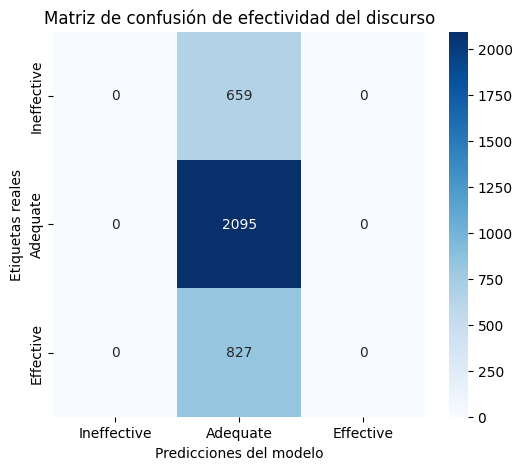

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calcular matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

# Etiquetas de tus clases
class_names = ['Ineffective', 'Adequate', 'Effective']

# Mostrar matriz como texto
print("\nMatriz de confusión:")
print(cm)

# Visualización más clara con seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicciones del modelo")
plt.ylabel("Etiquetas reales")
plt.title("Matriz de confusión de efectividad del discurso")
plt.show()


In [17]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Como era de esperarse las metricas que se obtuvieron de este modelo son son malas, teniendo un accuracy de 19% siendo incapaz de entender la informacion.

In [18]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print("\n===== MÉTRICAS GLOBALES =====")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-score (macro):  {f1:.4f}")


===== MÉTRICAS GLOBALES =====
Accuracy:  0.5850
Precision (macro): 0.1950
Recall (macro):    0.3333
F1-score (macro):  0.2461


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
class_names = ['Ineffective', 'Adequate', 'Effective']
print("\n===== REPORTE POR CLASE =====")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


===== REPORTE POR CLASE =====
              precision    recall  f1-score   support

 Ineffective     0.0000    0.0000    0.0000       659
    Adequate     0.5850    1.0000    0.7382      2095
   Effective     0.0000    0.0000    0.0000       827

    accuracy                         0.5850      3581
   macro avg     0.1950    0.3333    0.2461      3581
weighted avg     0.3423    0.5850    0.4319      3581



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


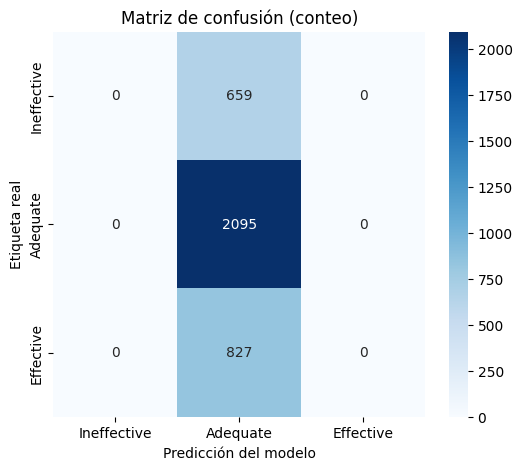

In [20]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción del modelo')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión (conteo)')
plt.show()

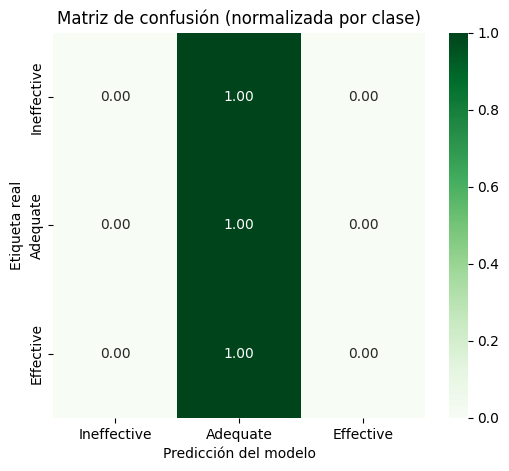

In [21]:
cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción del modelo')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión (normalizada por clase)')
plt.show()

In [22]:
import pandas as pd
from collections import Counter

label_map = {0: 'Ineffective', 1: 'Adequate', 2: 'Effective'}

# Contar etiquetas verdaderas
true_counts = Counter(all_labels)
true_df = pd.DataFrame({
    'Clase': [label_map[k] for k in true_counts.keys()],
    'Cantidad real': [v for v in true_counts.values()]
})

print("\n===== DISTRIBUCIÓN REAL =====")
print(true_df)



===== DISTRIBUCIÓN REAL =====
         Clase  Cantidad real
0     Adequate           2095
1    Effective            827
2  Ineffective            659


### Modelo 2

Debido a el desbalance de las clases se decidio cambiar el enfoque. Se decidio asignarle pesos de perdia distintos a las clases para que incpacten mas las clases minoritarias y no tener que crear nueva data.

In [36]:
class EssayGroupModel2(nn.Module):
    """
    Model that processes full essays and predicts effectiveness for each discourse.

    How it works:
    1. Takes ONE full essay as input
    2. Passes it through the backbone (DeBERTa/RoBERTa)
    3. Pools embeddings between [START] and [END] tokens for each discourse
    4. Predicts effectiveness for each discourse independently
    """

    def __init__(
        self,
        model_name='microsoft/deberta-base',
        num_labels=3,  # Inadequate, Adequate, Effective
        dropout=0.1
    ):
        super().__init__()

        # Load pretrained backbone
        print(f"Loading pretrained model: {model_name}")
        self.backbone = AutoModel.from_pretrained(model_name)
        self.config = self.backbone.config
        self.hidden_size = self.config.hidden_size

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # Final classification layer
        self.classifier = nn.Linear(self.hidden_size, num_labels)

        print(f"Model initialized with hidden_size={self.hidden_size}")

    def resize_token_embeddings(self, new_num_tokens):
        """
        Call this after adding special tokens to the tokenizer.
        This resizes the model's embedding layer to accommodate new tokens.
        """
        self.backbone.resize_token_embeddings(new_num_tokens)
        print(f"Resized token embeddings to {new_num_tokens}")

    def find_start_end_positions(self, input_ids, start_token_id, end_token_id):
        """
        Find all [START] and [END] token positions in the input.

        Args:
            input_ids: [seq_len] tensor of token IDs
            start_token_id: ID of [START] token
            end_token_id: ID of [END] token

        Returns:
            start_positions: List of start token positions
            end_positions: List of end token positions
        """
        start_positions = []
        end_positions = []

        for i, token_id in enumerate(input_ids):
            if token_id == start_token_id:
                start_positions.append(i)
            elif token_id == end_token_id:
                end_positions.append(i)

        return start_positions, end_positions

    def pool_discourse_embeddings(self, sequence_output, start_positions, end_positions):
        """
        Pool embeddings between [START] and [END] tokens for each discourse.

        Args:
            sequence_output: [seq_len, hidden_size] - output from backbone
            start_positions: List of start token positions
            end_positions: List of end token positions

        Returns:
            pooled_embeddings: [num_discourses, hidden_size]
        """
        num_discourses = len(start_positions)
        pooled_embeddings = []

        for i in range(num_discourses):
            start_idx = start_positions[i]
            end_idx = end_positions[i]

            # Extract tokens between START and END (exclusive of the markers)
            # discourse_embeddings shape: [num_tokens_in_discourse, hidden_size]
            discourse_embeddings = sequence_output[start_idx + 1:end_idx]

            if len(discourse_embeddings) == 0:
                # If empty (shouldn't happen), use the START token
                pooled = sequence_output[start_idx]
            else:
                # Mean pooling
                pooled = discourse_embeddings.mean(dim=0)

            pooled_embeddings.append(pooled)

        # Stack into tensor: [num_discourses, hidden_size]
        pooled_embeddings = torch.stack(pooled_embeddings, dim=0)

        return pooled_embeddings

    def forward(
        self,
        input_ids,
        attention_mask,
        start_token_id,
        end_token_id,
        labels=None,
        loss_fct=None
    ):
        """
        Forward pass.

        Args:
            input_ids: [batch_size=1, seq_len] - tokenized essay
            attention_mask: [batch_size=1, seq_len] - attention mask
            start_token_id: int - ID of [START] token
            end_token_id: int - ID of [END] token
            labels: [num_discourses] - effectiveness labels (optional, for training)
            loss_fct: función de pérdida opcional (ej. ponderada)
        """
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = outputs.last_hidden_state
        sequence_output = sequence_output.squeeze(0)
        input_ids_1d = input_ids.squeeze(0)

        start_positions, end_positions = self.find_start_end_positions(
            input_ids_1d, start_token_id, end_token_id
        )

        pooled_embeddings = self.pool_discourse_embeddings(
            sequence_output, start_positions, end_positions
        )

        pooled_embeddings = self.dropout(pooled_embeddings)
        logits = self.classifier(pooled_embeddings)
        probabilities = torch.softmax(logits, dim=-1)

        # Usa el loss_fct externo si se pasa
        loss = None
        if labels is not None:
            if loss_fct is not None:
                loss = loss_fct(logits, labels)
            else:
                default_loss = nn.CrossEntropyLoss()
                loss = default_loss(logits, labels)

        return {
            'loss': loss,
            'logits': logits,
            'probabilities': probabilities,
            'num_discourses': len(start_positions)
        }



In [72]:
from transformers import AutoTokenizer
import torch

model = EssayGroupModel2(
    model_name='microsoft/deberta-base',
    num_labels=3,
    dropout=0.1
)

tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-base', use_fast=False)
tokenizer.add_special_tokens({'additional_special_tokens': ['[START]', '[END]']})

model.resize_token_embeddings(len(tokenizer))

print(f"\nModelo y tokenizer listos:")
print(f"  Tokens totales: {len(tokenizer)}")
print(f"  Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")


Loading pretrained model: microsoft/deberta-base
Model initialized with hidden_size=768
Resized token embeddings to 50267

Modelo y tokenizer listos:
  Tokens totales: 50267
  Parámetros totales: 138,605,571


Se agregan los pesos al modelo

In [40]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=all_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
weighted_loss = nn.CrossEntropyLoss(weight=class_weights)

print("Pesos de clase:", class_weights)

Pesos de clase: tensor([1.8113, 0.5698, 1.4434])


In [41]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)


In [42]:
dummy_text = "Intro [SEP] [START] This is the first discourse. [END] [START] This is the second one. [END]"

encoding = tokenizer(
    dummy_text,
    return_tensors='pt',
    max_length=512,
    padding='max_length',
    truncation=True
)

dummy_labels = torch.tensor([1, 2])

outputs = model(
    input_ids=encoding['input_ids'],
    attention_mask=encoding['attention_mask'],
    start_token_id=tokenizer.convert_tokens_to_ids('[START]'),
    end_token_id=tokenizer.convert_tokens_to_ids('[END]'),
    labels=dummy_labels,
    loss_fct=weighted_loss
)

print(f"Loss: {outputs['loss'].item():.4f}")
print(f"Logits shape: {outputs['logits'].shape}")
print(f"Probabilities:\n{outputs['probabilities']}")


Loss: 1.2618
Logits shape: torch.Size([2, 3])
Probabilities:
tensor([[0.3936, 0.3699, 0.2365],
        [0.3917, 0.3535, 0.2548]], grad_fn=<SoftmaxBackward0>)


In [43]:
def train_step(model, batch, optimizer, device, tokenizer, loss_fct=None):
    model.train()

    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].squeeze(0).to(device)

    start_token_id = tokenizer.convert_tokens_to_ids('[START]')
    end_token_id = tokenizer.convert_tokens_to_ids('[END]')

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        start_token_id=start_token_id,
        end_token_id=end_token_id,
        labels=labels,
        loss_fct=loss_fct
    )

    loss = outputs['loss']
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    return loss.item(), outputs['num_discourses']


In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

model.to(device)

weighted_loss = weighted_loss.to(device)


Usando dispositivo: cuda


In [54]:
from tqdm import tqdm
import numpy as np

num_epochs = 5
best_val_loss = float('inf')

for epoch in range(num_epochs):
    print(f"\n===== EPOCH {epoch + 1}/{num_epochs} =====")

    train_losses = []

    for batch in tqdm(train_loader, desc="Training"):
        loss, num_disc = train_step(model, batch, optimizer, device, tokenizer, loss_fct=weighted_loss)
        train_losses.append(loss)

    avg_train_loss = np.mean(train_losses)

    val_losses = []
    for batch in tqdm(val_loader, desc="Validation"):
        loss, preds, labels = eval_step(model, batch, device, tokenizer)
        val_losses.append(loss)

    avg_val_loss = np.mean(val_losses)

    print(f"\nEpoch {epoch + 1} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("✅ Nuevo mejor modelo guardado.")



===== EPOCH 1/5 =====


Validation: 100%|██████████| 420/420 [01:24<00:00,  4.98it/s]



Epoch 1 Summary:
  Train Loss: 0.5657
  Val Loss:   0.8293
✅ Nuevo mejor modelo guardado.

===== EPOCH 2/5 =====


Validation: 100%|██████████| 420/420 [01:23<00:00,  5.02it/s]



Epoch 2 Summary:
  Train Loss: 0.4568
  Val Loss:   1.0255

===== EPOCH 3/5 =====


...


Epoch 3 Summary:
  Train Loss: 0.3769
  Val Loss:   1.2273

===== EPOCH 4/5 =====


Validation: 100%|██████████| 420/420 [01:24<00:00,  4.98it/s]



Epoch 4 Summary:
  Train Loss: 0.3201
  Val Loss:   1.4322

===== EPOCH 5/5 =====


Validation: 100%|██████████| 420/420 [01:24<00:00,  5.00it/s]


Epoch 5 Summary:
  Train Loss: 0.2650
  Val Loss:   1.6664


### Modelo 2 - 1

In [49]:
torch.save(model, "essay_model_full.pt")

In [50]:
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

all_preds = []
all_labels = []
val_losses = []

model.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluando modelo final"):
        loss, preds, labels = eval_step(model, batch, device, tokenizer)
        val_losses.append(loss)
        all_preds.extend(preds.argmax(axis=1))
        all_labels.extend(labels)

avg_val_loss = np.mean(val_losses)


Evaluando modelo final: 100%|██████████| 420/420 [01:24<00:00,  4.99it/s]


In [51]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print("\n===== MÉTRICAS FINALES =====")
print(f"  Loss promedio: {avg_val_loss:.4f}")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-score:  {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds)
print("\nMatriz de Confusión:")
print(cm)

print("\nReporte por clase:")
print(classification_report(all_labels, all_preds, target_names=["Ineffective", "Adequate", "Effective"], zero_division=0))



===== MÉTRICAS FINALES =====
  Loss promedio: 0.7153
  Accuracy:  0.6655
  Precision: 0.6242
  Recall:    0.6415
  F1-score:  0.6215

Matriz de Confusión:
[[ 250  338   31]
 [ 227 1363  496]
 [   4  119  804]]

Reporte por clase:
              precision    recall  f1-score   support

 Ineffective       0.52      0.40      0.45       619
    Adequate       0.75      0.65      0.70      2086
   Effective       0.60      0.87      0.71       927

    accuracy                           0.67      3632
   macro avg       0.62      0.64      0.62      3632
weighted avg       0.67      0.67      0.66      3632



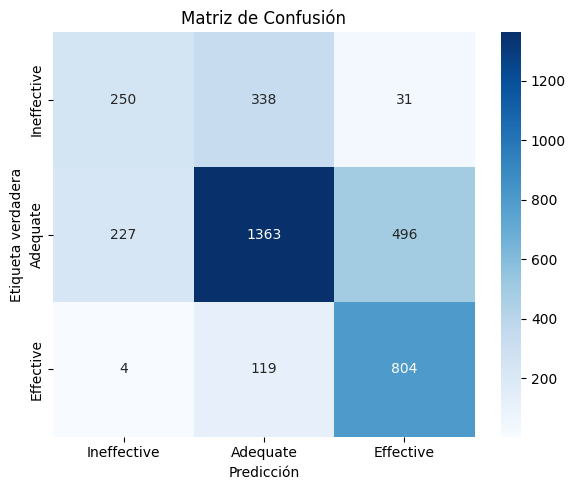

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [250, 338, 31],
    [227, 1363, 496],
    [4, 119, 804]
])

labels = ['Ineffective', 'Adequate', 'Effective']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicción')
plt.ylabel('Etiqueta verdadera')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()


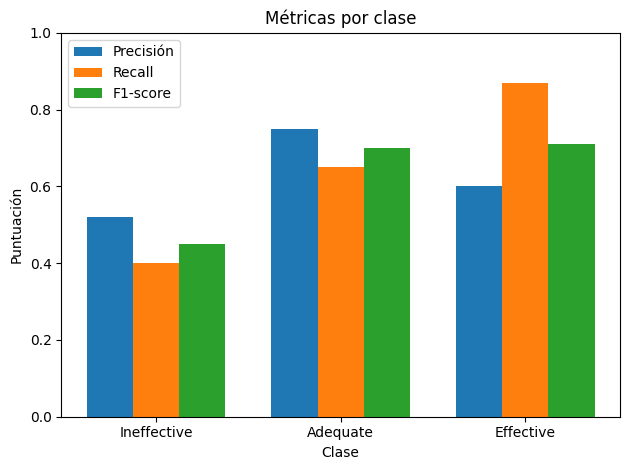

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
classes = ['Ineffective', 'Adequate', 'Effective']
precision = [0.52, 0.75, 0.60]
recall = [0.40, 0.65, 0.87]
f1 = [0.45, 0.70, 0.71]

x = np.arange(len(classes))
width = 0.25

# Crear gráfico
plt.bar(x - width, precision, width, label='Precisión')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.xlabel('Clase')
plt.ylabel('Puntuación')
plt.title('Métricas por clase')
plt.legend()
plt.tight_layout()
plt.show()


### Modelo 2 - 2

In [ ]:
model = EssayGroupModel2(
    model_name='microsoft/deberta-v3-large,
    num_labels=3,
    dropout=0.1
)

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [56]:
model.load_state_dict(torch.load("./best_model.pt", map_location=device))

<All keys matched successfully>

In [57]:
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

all_preds = []
all_labels = []
val_losses = []

model.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluando modelo final"):
        loss, preds, labels = eval_step(model, batch, device, tokenizer)
        val_losses.append(loss)
        all_preds.extend(preds.argmax(axis=1))
        all_labels.extend(labels)

avg_val_loss = np.mean(val_losses)


Evaluando modelo final: 100%|██████████| 420/420 [01:24<00:00,  4.99it/s]


In [58]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print("\n===== MÉTRICAS FINALES =====")
print(f"  Loss promedio: {avg_val_loss:.4f}")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-score:  {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds)
print("\nMatriz de Confusión:")
print(cm)

print("\nReporte por clase:")
print(classification_report(all_labels, all_preds, target_names=["Ineffective", "Adequate", "Effective"], zero_division=0))



===== MÉTRICAS FINALES =====
  Loss promedio: 0.8293
  Accuracy:  0.6707
  Precision: 0.6215
  Recall:    0.6478
  F1-score:  0.6316

Matriz de Confusión:
[[ 285  318   16]
 [ 332 1397  357]
 [  19  154  754]]

Reporte por clase:
              precision    recall  f1-score   support

 Ineffective       0.45      0.46      0.45       619
    Adequate       0.75      0.67      0.71      2086
   Effective       0.67      0.81      0.73       927

    accuracy                           0.67      3632
   macro avg       0.62      0.65      0.63      3632
weighted avg       0.68      0.67      0.67      3632



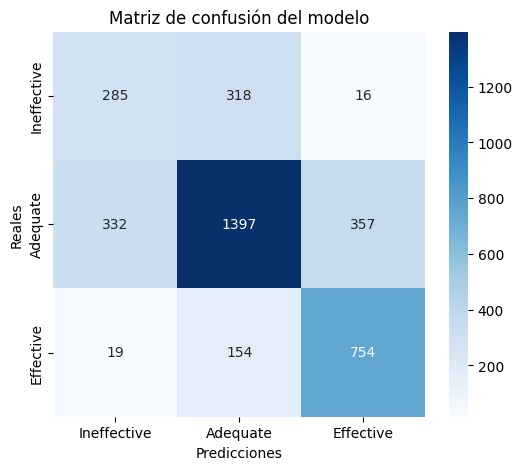

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
labels = ["Ineffective", "Adequate", "Effective"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicciones")
plt.ylabel("Reales")
plt.title("Matriz de confusión del modelo")
plt.show()


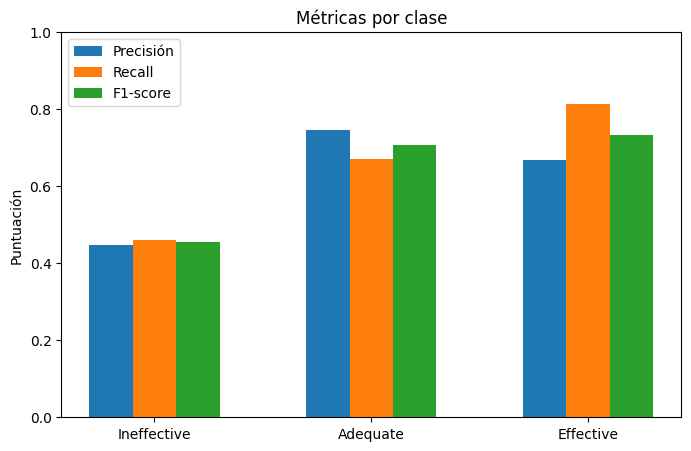

In [62]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

precisions, recalls, f1s, _ = precision_recall_fscore_support(
    all_labels, all_preds, average=None, zero_division=0)

x = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, precisions, width=0.2, label='Precisión')
plt.bar(x, recalls, width=0.2, label='Recall')
plt.bar(x + 0.2, f1s, width=0.2, label='F1-score')
plt.xticks(x, labels)
plt.ylabel("Puntuación")
plt.title("Métricas por clase")
plt.legend()
plt.ylim(0, 1)
plt.show()


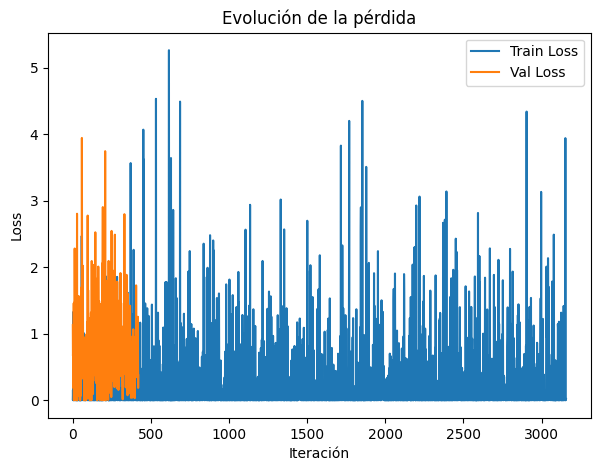

In [65]:
plt.figure(figsize=(7,5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Val Loss")
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.title("Evolución de la pérdida")
plt.legend()
plt.show()


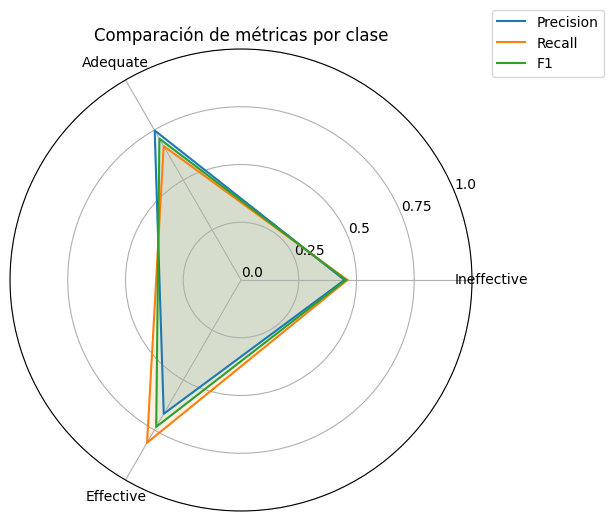

In [66]:
from math import pi

metrics = [precisions, recalls, f1s]
metric_names = ['Precision', 'Recall', 'F1']

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

for i, metric in enumerate(metrics):
    stats = np.concatenate((metric, [metric[0]]))
    ax.plot(angles, stats, label=metric_names[i])
    ax.fill(angles, stats, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticks(np.linspace(0,1,5))
ax.set_yticklabels(['0.0','0.25','0.5','0.75','1.0'])
plt.title("Comparación de métricas por clase")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


In [59]:
torch.save(model, "essay_model2_full.pt")

In [52]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#!cp /content/essay_model2_full.pt /content/drive/MyDrive/